# Word Cloud of "The Adventures of Tom Sawyer"

Load Data: Full text of `The Adventures of Tom Sawyer`

In [ ]:
# Note: We can get the online text data using the famous `requests` package!
# You can download the text file directly from URL

# import requests
# response = requests.get("https://www.gutenberg.org/cache/epub/74/pg74.txt")
# text = response.text

# ---

# Or you can read the text file if you have already downloaded it
with open("./data/en_tom_sawyer.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text[:200])

The Project Gutenberg eBook of The Adventures of Tom Sawyer, Complete
    
This ebook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almos


### 1. Draw Wordcloud (without any text processing)

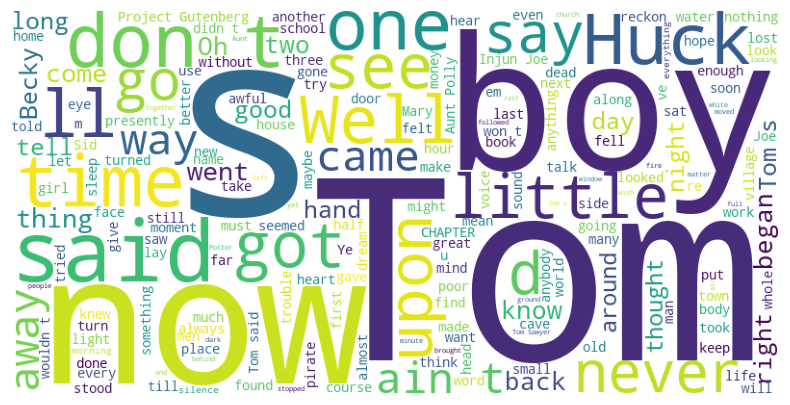

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### 2. Draw Wordcloud with an appropriate text processing

In [3]:
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.corpus import stopwords


def get_preprocessed_corpus(text, custom_stopwords=None):
    text = text.lower()
    words = word_tokenize(text)
    tagged = pos_tag(words)
    words = [w for w, pos in tagged if pos[0] == 'N'] # keep only nouns

    stop_words_list = stopwords.words('english')
    if custom_stopwords is not None:
        stop_words_list += custom_stopwords  # Add any custom stopwords if needed
    words_filtered = [w for w in words if not w in stop_words_list]
    return ' '.join(words_filtered)


def draw_wordcloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()

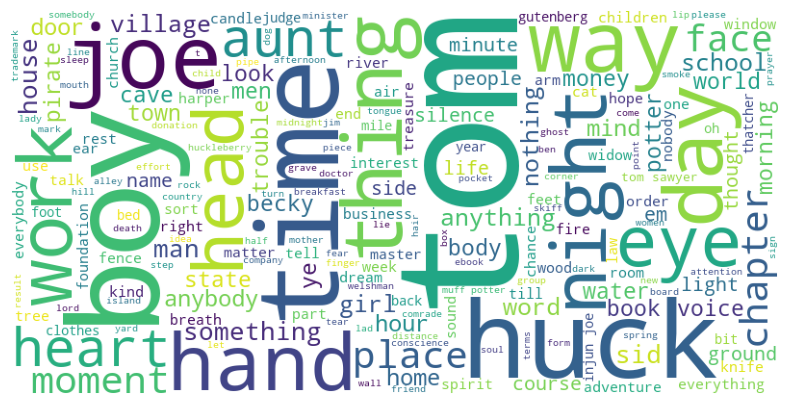

In [4]:
custom_stopwords = ['project', 'gutenberg', ]
text_preprocessed = get_preprocessed_corpus(text, custom_stopwords=custom_stopwords)
draw_wordcloud(text_preprocessed)